In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import numpy as np

In [3]:
df = pd.read_csv("./data/train.csv")

In [4]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [6]:
missing_counts = df.isna()
missing_counts[missing_counts > 0]

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,NaN,NaN,NaN,NaN,NaN,NaN,True,NaN,NaN,NaN,...,NaN,True,True,True,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,True,NaN,NaN,NaN,...,NaN,True,True,True,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,True,NaN,NaN,NaN,...,NaN,True,True,True,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,True,NaN,NaN,NaN,...,NaN,True,True,True,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,True,NaN,NaN,NaN,...,NaN,True,True,True,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,NaN,NaN,NaN,NaN,NaN,NaN,True,NaN,NaN,NaN,...,NaN,True,True,True,NaN,NaN,NaN,NaN,NaN,NaN
1456,NaN,NaN,NaN,NaN,NaN,NaN,True,NaN,NaN,NaN,...,NaN,True,NaN,True,NaN,NaN,NaN,NaN,NaN,NaN
1457,NaN,NaN,NaN,NaN,NaN,NaN,True,NaN,NaN,NaN,...,NaN,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1458,NaN,NaN,NaN,NaN,NaN,NaN,True,NaN,NaN,NaN,...,NaN,True,True,True,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
missing_counts = df.isna().sum()

(missing_counts[missing_counts > 0] / len(df) * 100).round(2)

LotFrontage     17.74
Alley           93.77
MasVnrType      59.73
MasVnrArea       0.55
BsmtQual         2.53
BsmtCond         2.53
BsmtExposure     2.60
BsmtFinType1     2.53
BsmtFinType2     2.60
Electrical       0.07
FireplaceQu     47.26
GarageType       5.55
GarageYrBlt      5.55
GarageFinish     5.55
GarageQual       5.55
GarageCond       5.55
PoolQC          99.52
Fence           80.75
MiscFeature     96.30
dtype: float64

In [8]:
cols_to_fill_none = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu', 'MasVnrType']
df[cols_to_fill_none] = df[cols_to_fill_none].fillna('None')

In [9]:
df['LotFrontage'] = df.groupby('Neighborhood')['LotFrontage'].transform(lambda x: x.fillna(x.median()))

In [10]:
def graph_show_to_price(parametr, bins=10, figsize=(14, 5)):
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    axes[0].scatter(df[parametr].sort_index(), df["SalePrice"], alpha=0.5)
    axes[0].set_title(f"Зависимость цены от {parametr}")
    axes[0].set_xlabel(f"{parametr}")
    axes[0].set_ylabel("SalePrice")

    if bins != -1:
        df[parametr].value_counts(bins=bins).sort_index().plot(kind="bar", ax=axes[1])
    else:
        df[parametr].value_counts().sort_index().plot(kind="bar", ax=axes[1])
    axes[1].set_title(f"Количество по категориям {parametr}")
    axes[1].set_xlabel(f"{parametr}")
    axes[1].set_ylabel("Количество")
    plt.tight_layout()
    plt.show()

<Axes: xlabel='MSSubClass'>

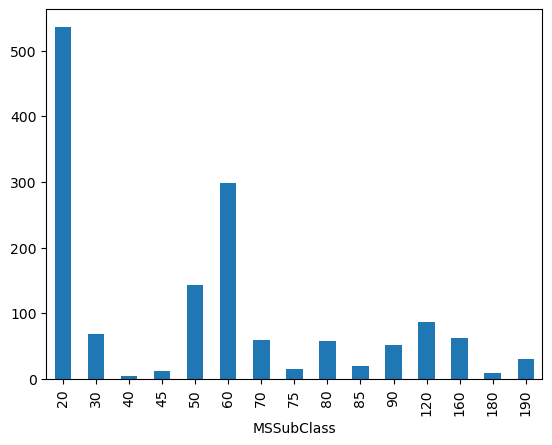

In [11]:
df["MSSubClass"].value_counts().sort_index().plot(kind="bar")



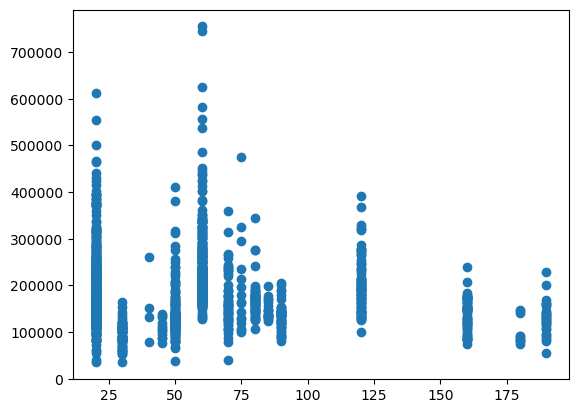

In [12]:
plt.scatter(df["MSSubClass"], df["SalePrice"])

<Axes: xlabel='MSZoning'>

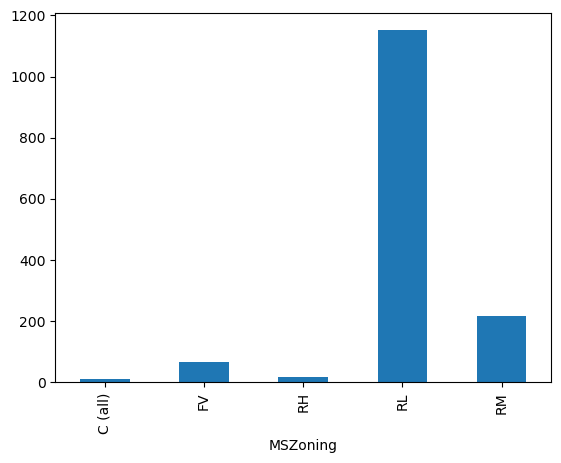

In [13]:
df["MSZoning"].value_counts().sort_index().plot(kind="bar")

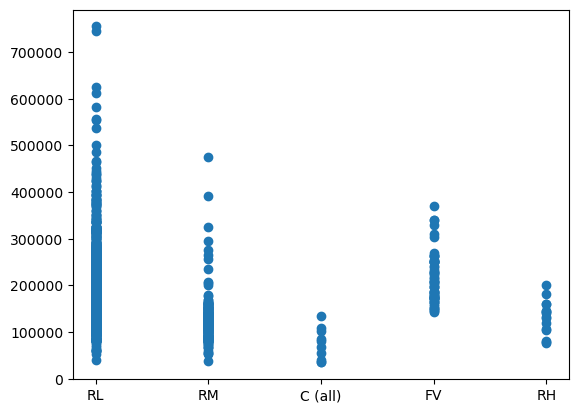

In [14]:
plt.scatter(df["MSZoning"], df["SalePrice"])

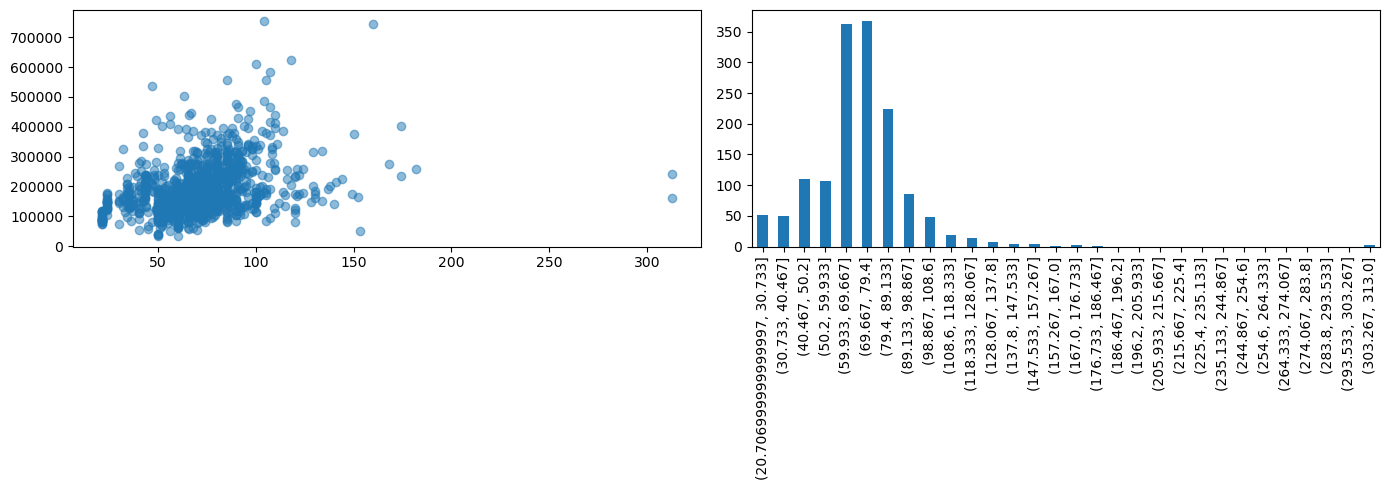

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
parametr = "LotFrontage"
axes[0].scatter(df[parametr], df["SalePrice"], alpha=0.5)
df[parametr].value_counts(bins=30).sort_index().plot(kind="bar", ax=axes[1])
plt.tight_layout()
plt.show()

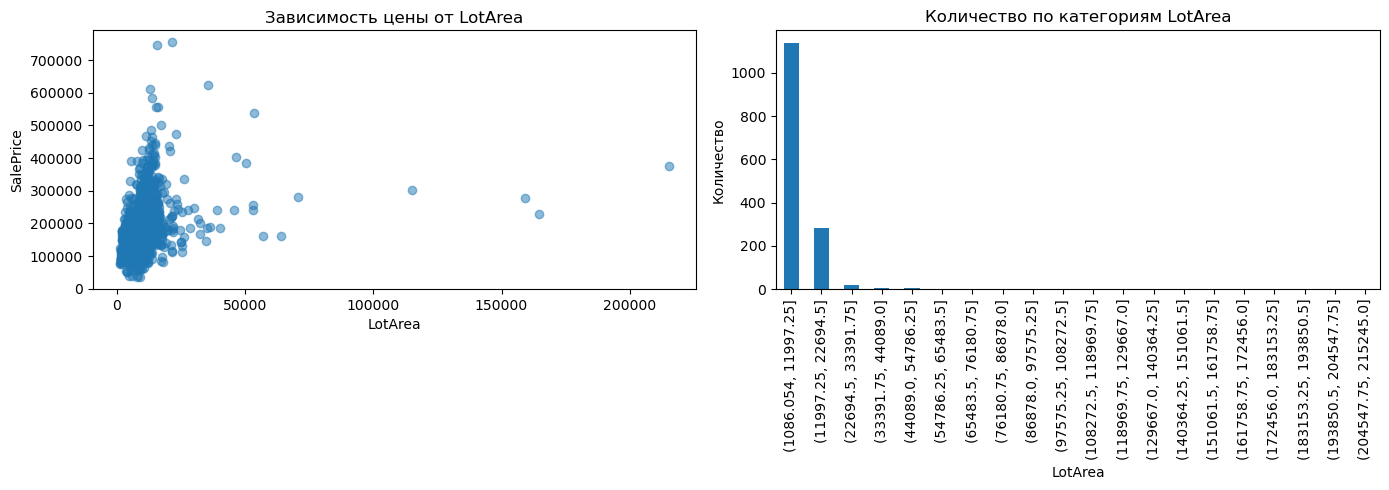

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
parametr = "LotArea"
axes[0].scatter(df[parametr], df["SalePrice"], alpha=0.5)
axes[0].set_title(f"Зависимость цены от {parametr}")
axes[0].set_xlabel(f"{parametr}")
axes[0].set_ylabel("SalePrice")


df[parametr].value_counts(bins=20).sort_index().plot(kind="bar", ax=axes[1])
axes[1].set_title(f"Количество по категориям {parametr}")
axes[1].set_xlabel(f"{parametr}")
axes[1].set_ylabel("Количество")
plt.tight_layout()
plt.show()

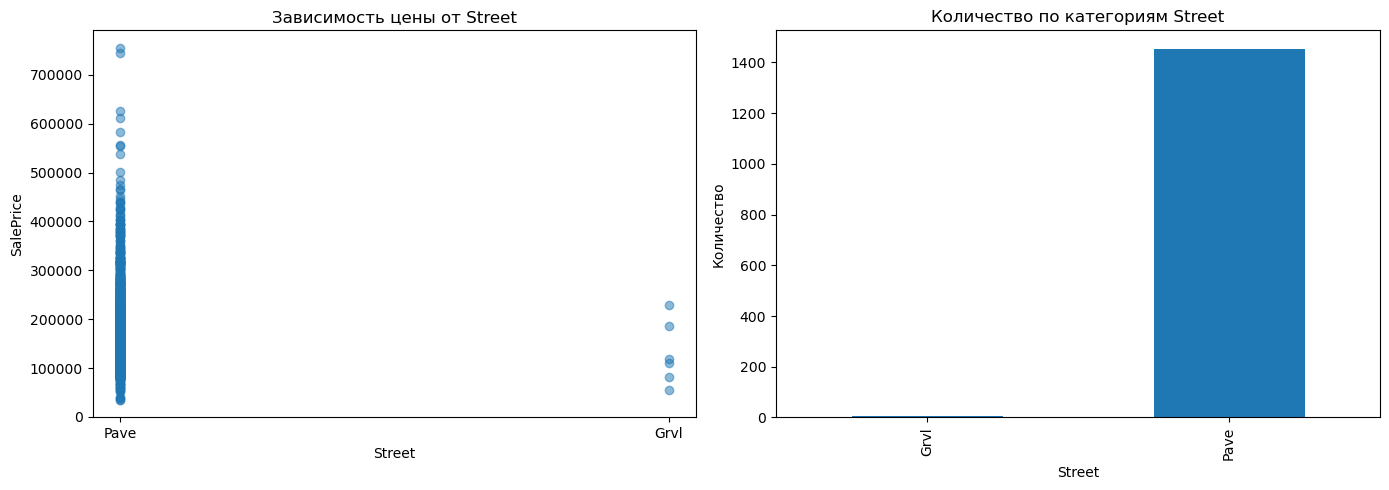

In [17]:
graph_show_to_price("Street", bins=-1)

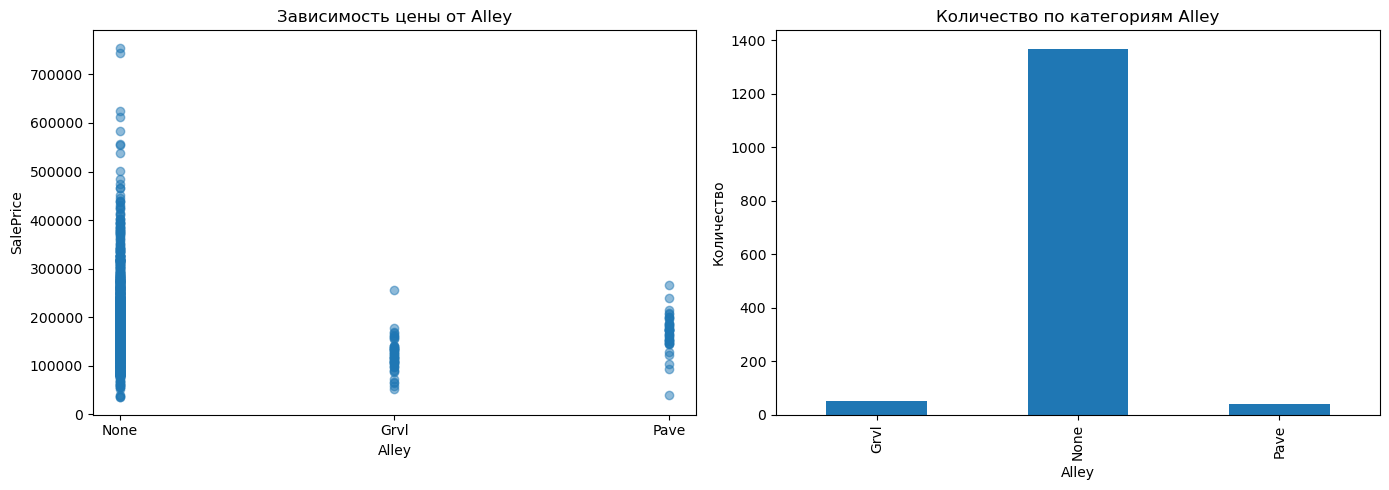

In [18]:
graph_show_to_price("Alley", bins=-1)

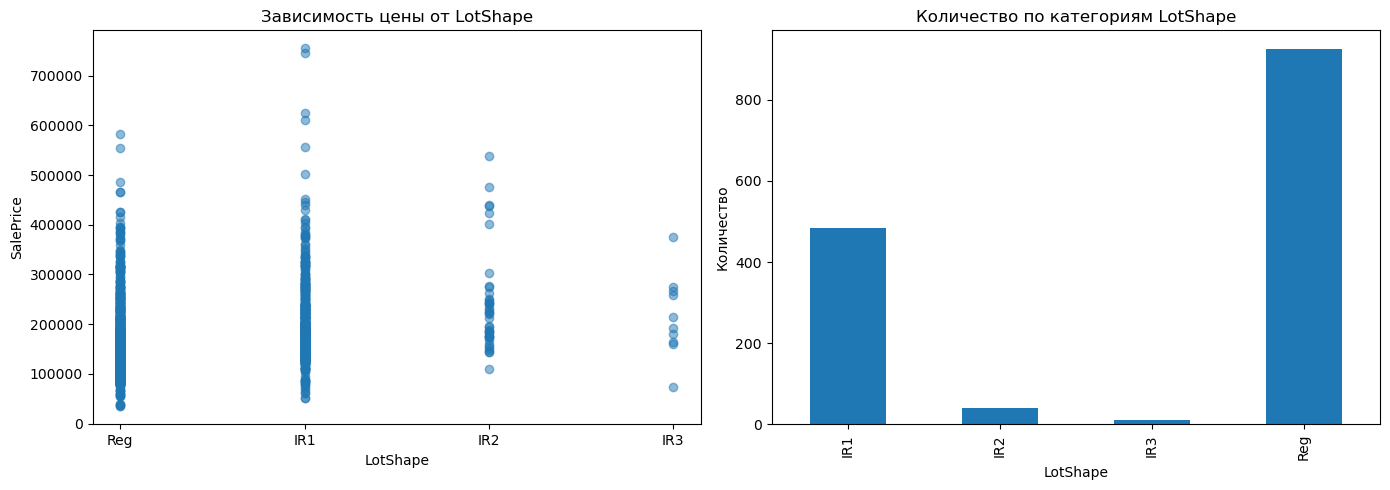

In [19]:
graph_show_to_price("LotShape", bins=-1)

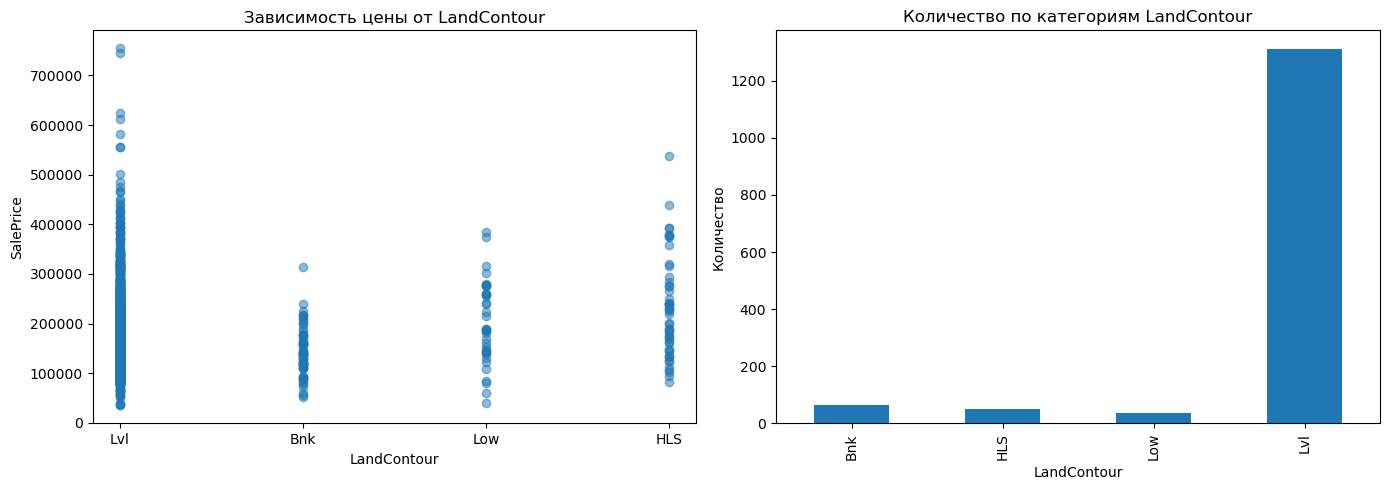

In [20]:
graph_show_to_price("LandContour", bins=-1)

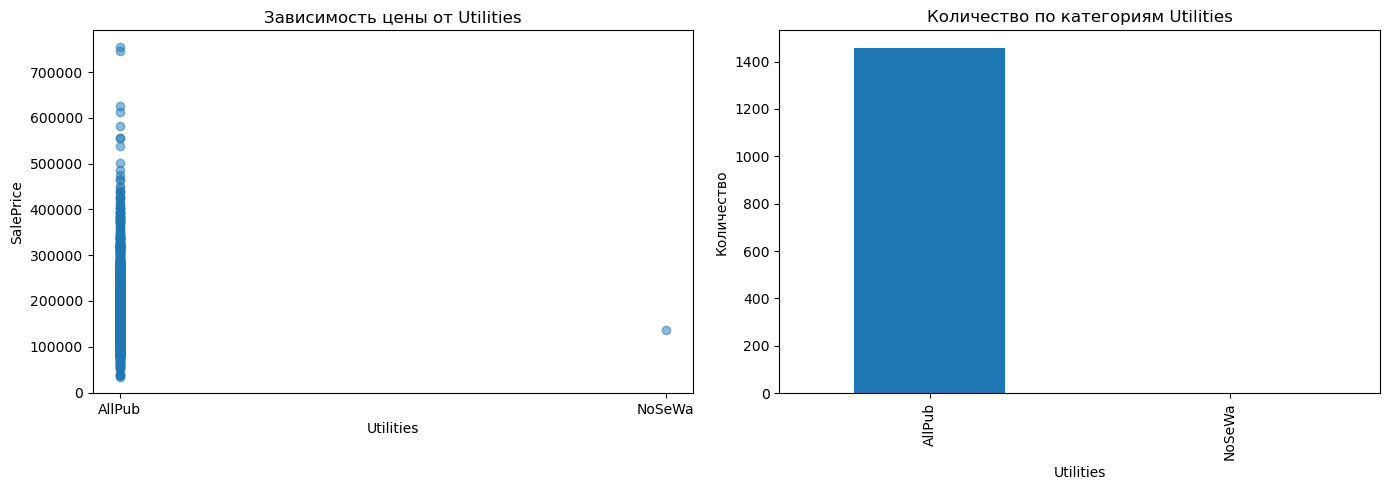

In [21]:
graph_show_to_price("Utilities", bins=-1)

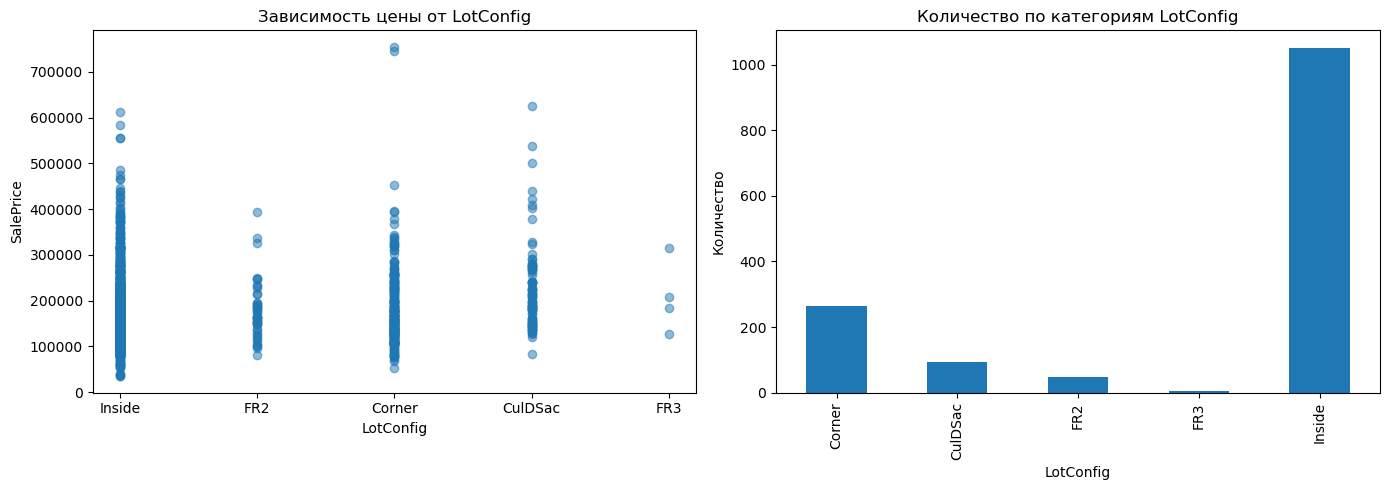

In [22]:
graph_show_to_price("LotConfig", bins=-1)

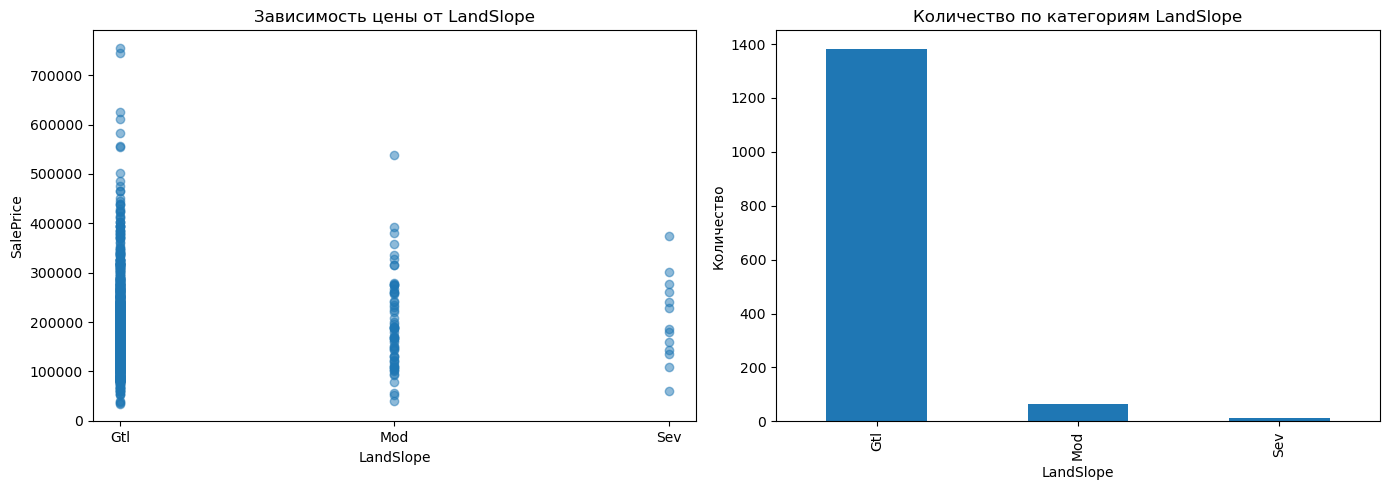

In [23]:
graph_show_to_price("LandSlope", bins=-1)

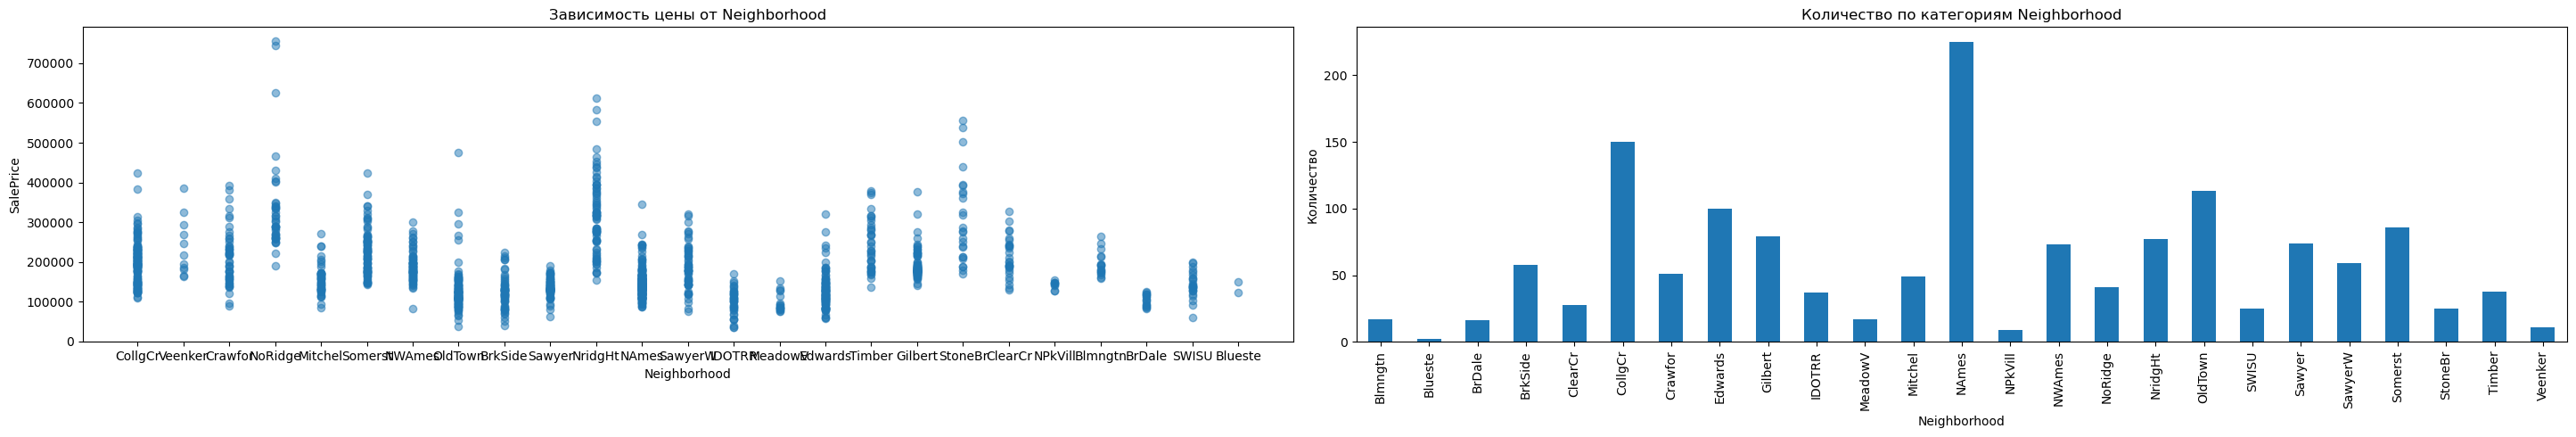

In [24]:
graph_show_to_price("Neighborhood", bins=-1, figsize=(29, 5))

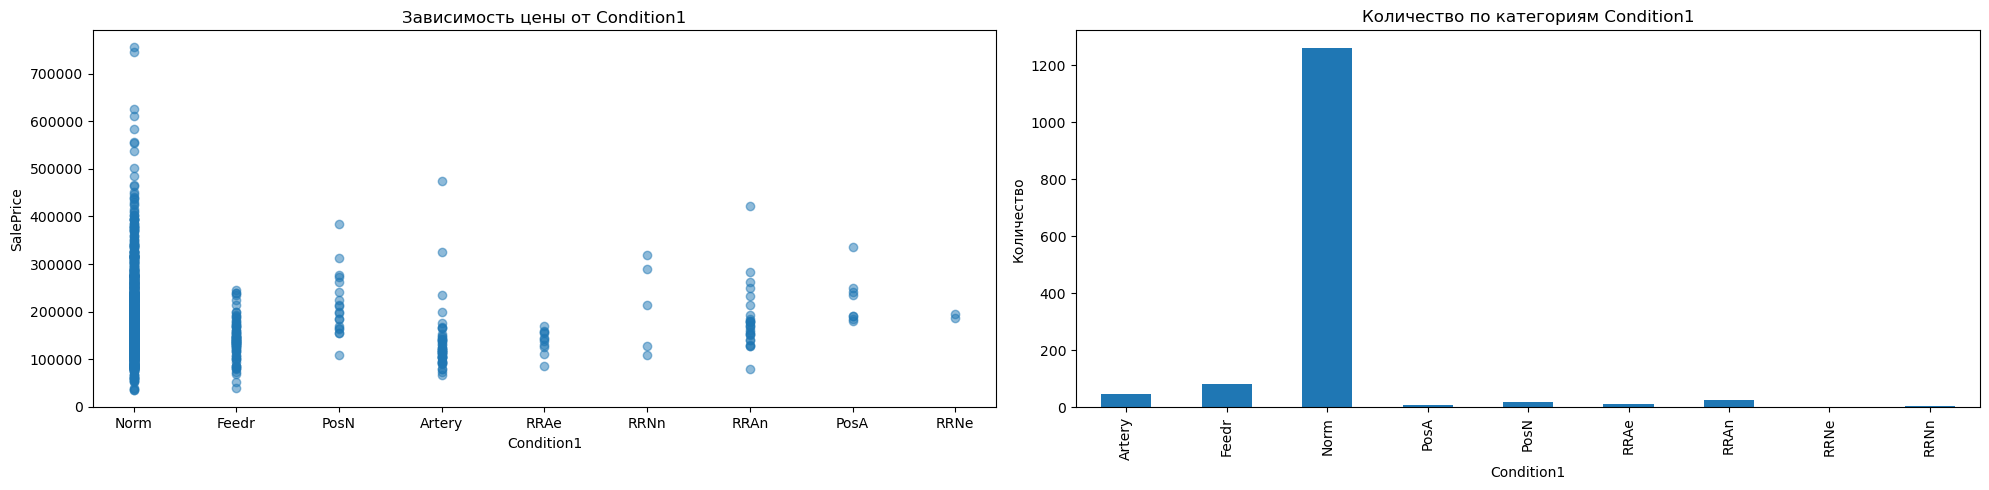

In [25]:
graph_show_to_price("Condition1", bins=-1, figsize=(20, 5))

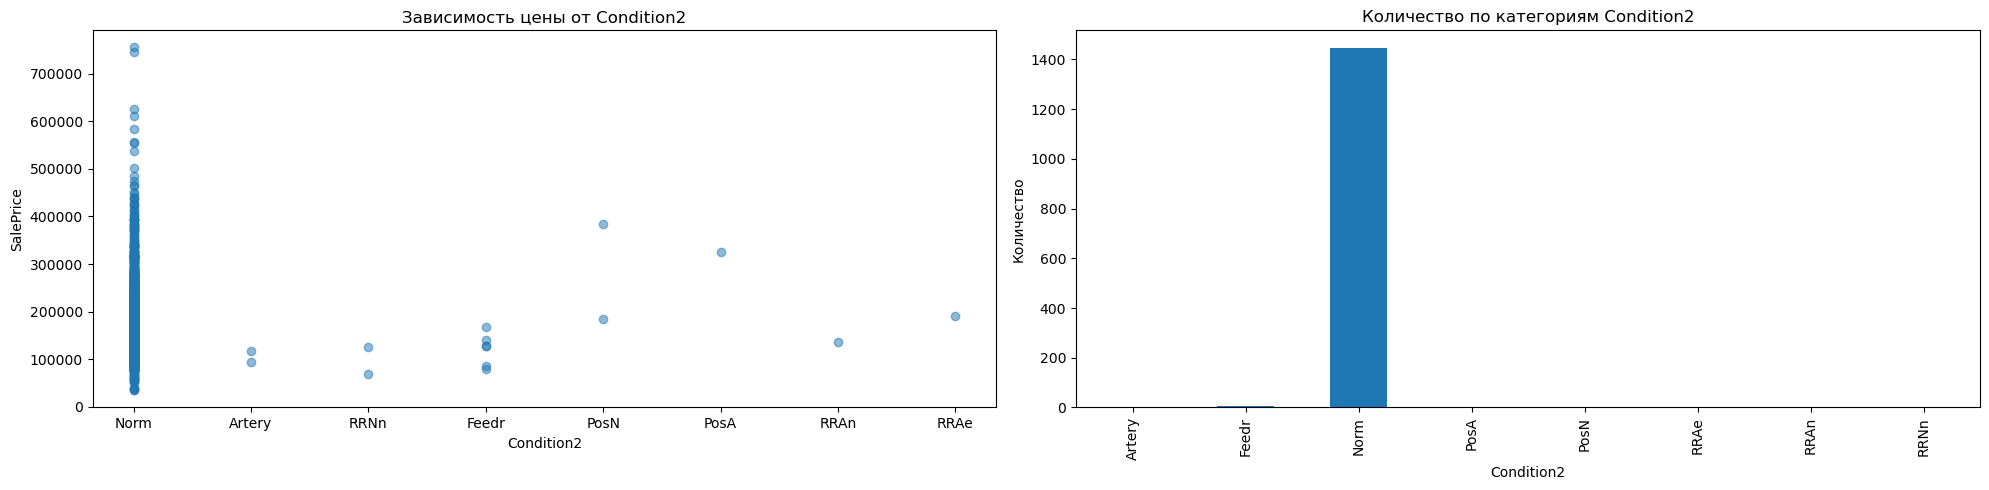

In [26]:
graph_show_to_price("Condition2", bins=-1, figsize=(20, 5))

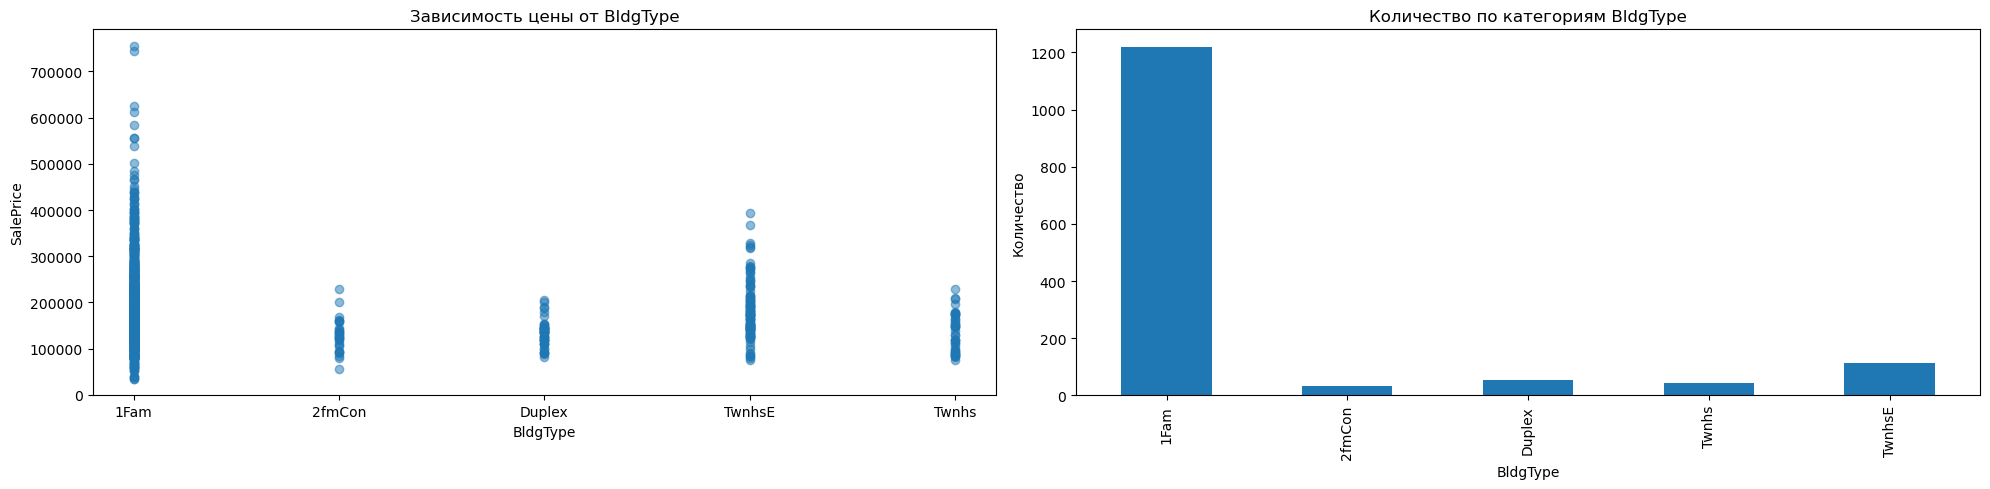

In [27]:
graph_show_to_price("BldgType", bins=-1, figsize=(20, 5))

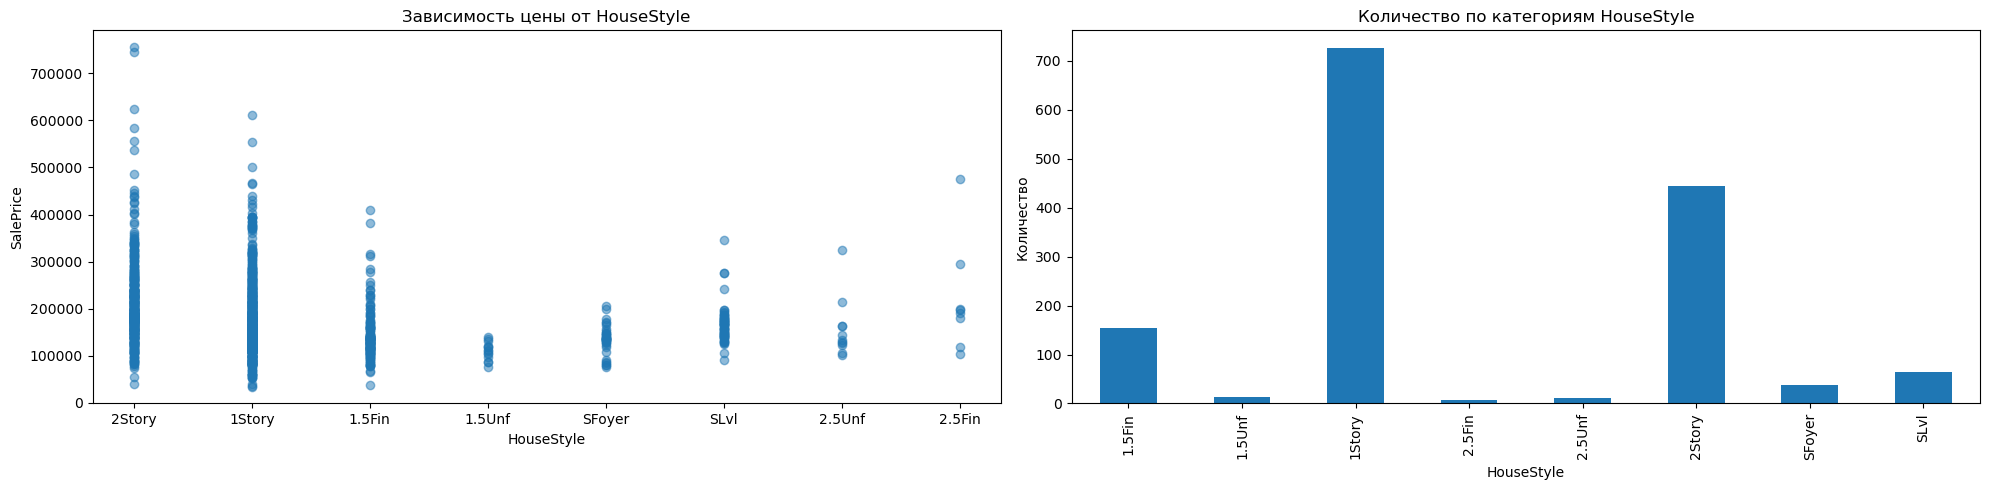

In [28]:
graph_show_to_price("HouseStyle", bins=-1, figsize=(20, 5))

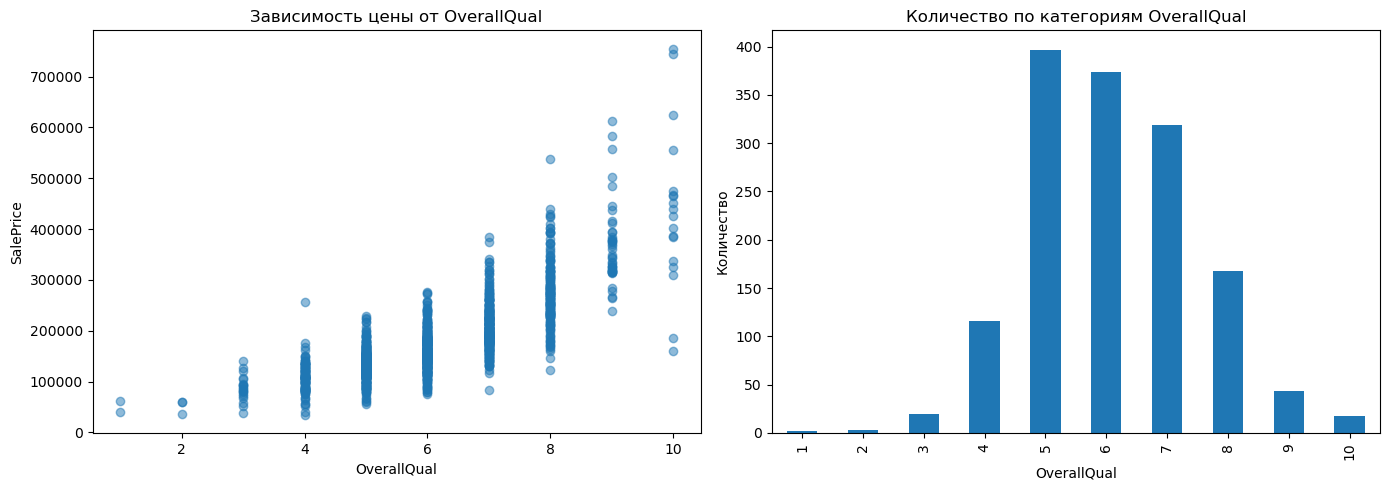

In [29]:
graph_show_to_price("OverallQual", bins=-1)

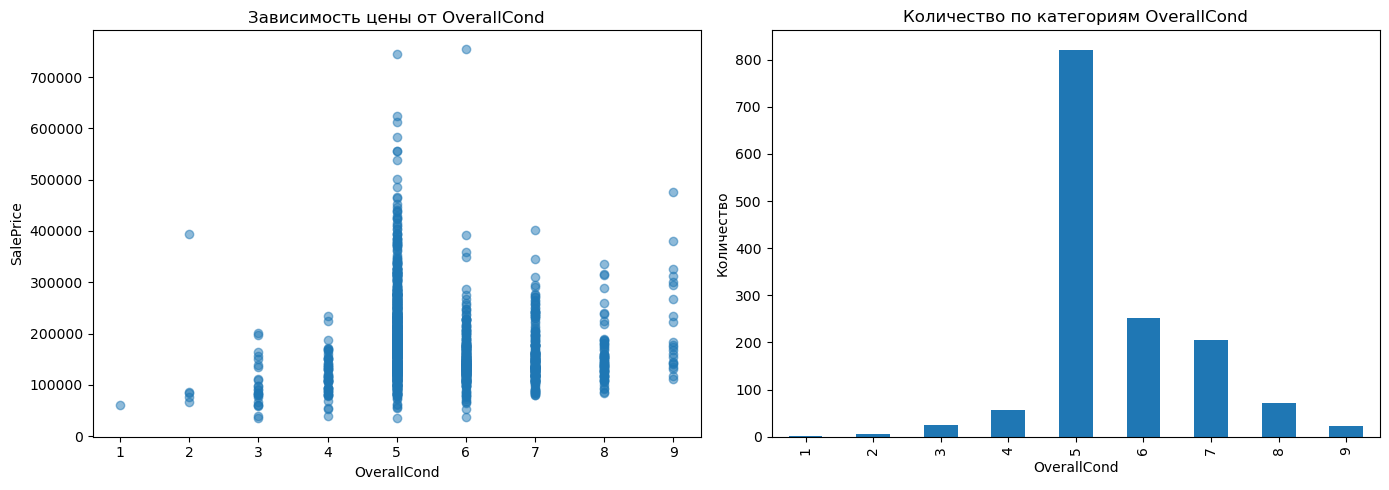

In [30]:
graph_show_to_price("OverallCond", bins=-1)

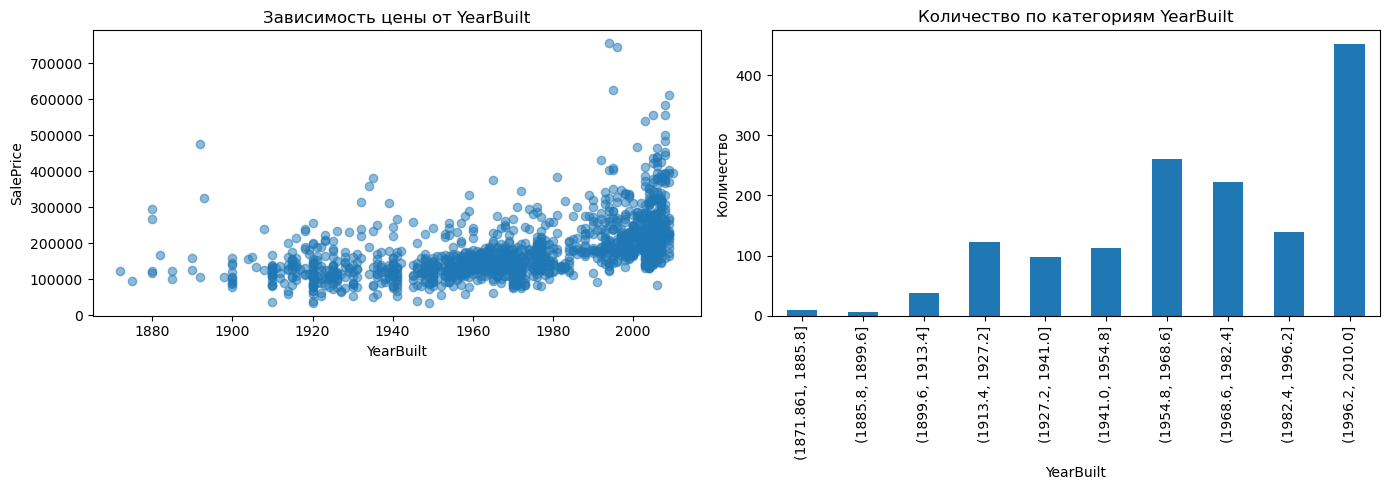

In [31]:
graph_show_to_price("YearBuilt", bins=10)

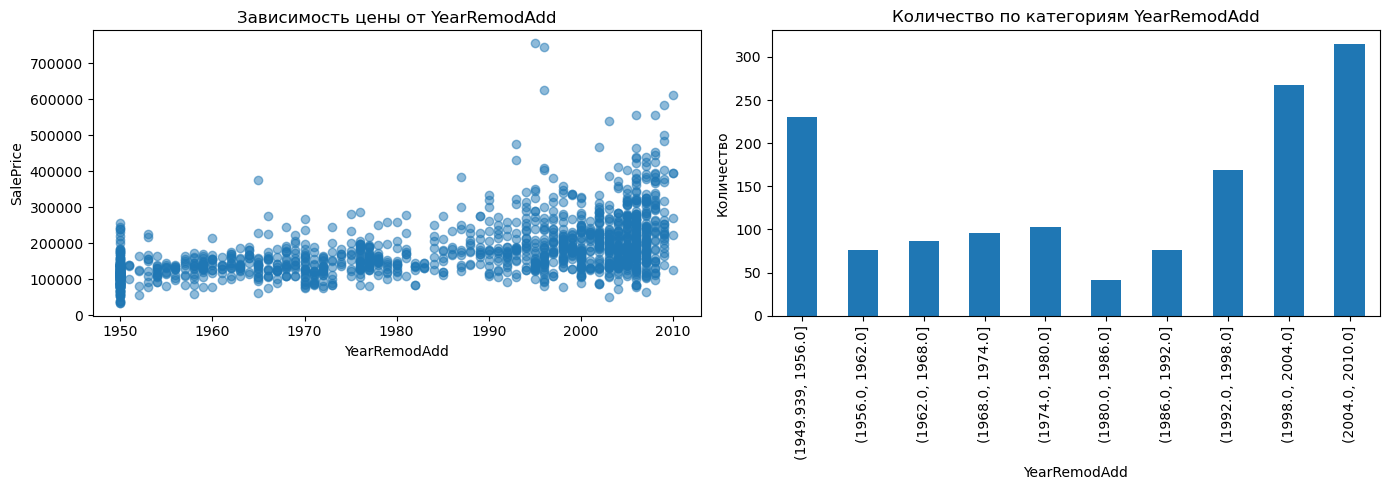

In [32]:
graph_show_to_price("YearRemodAdd", bins=10)

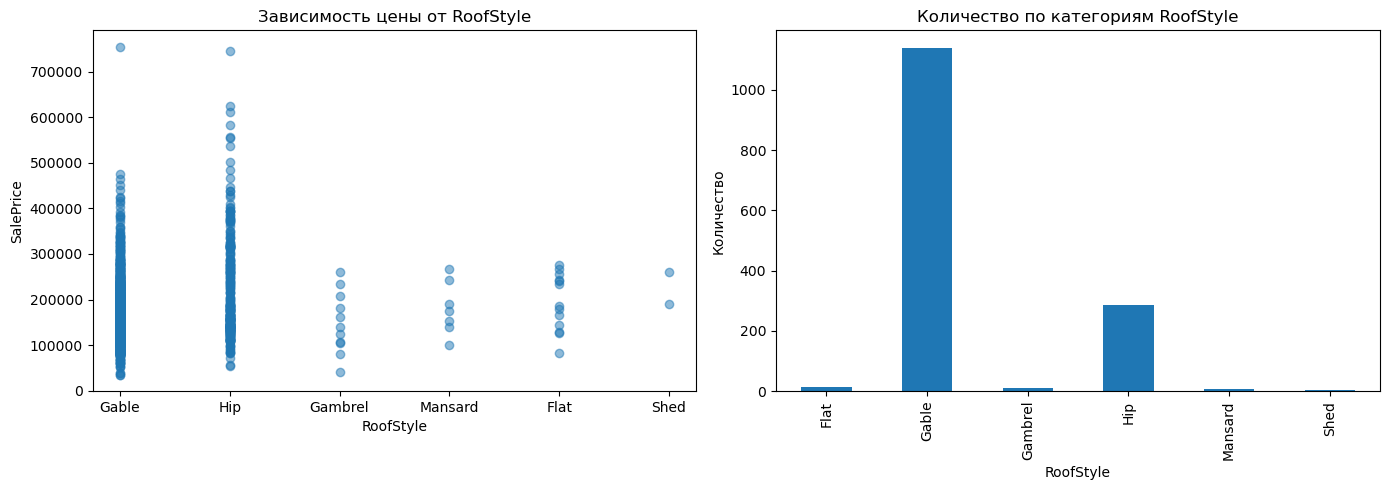

In [33]:
graph_show_to_price("RoofStyle", bins=-1)

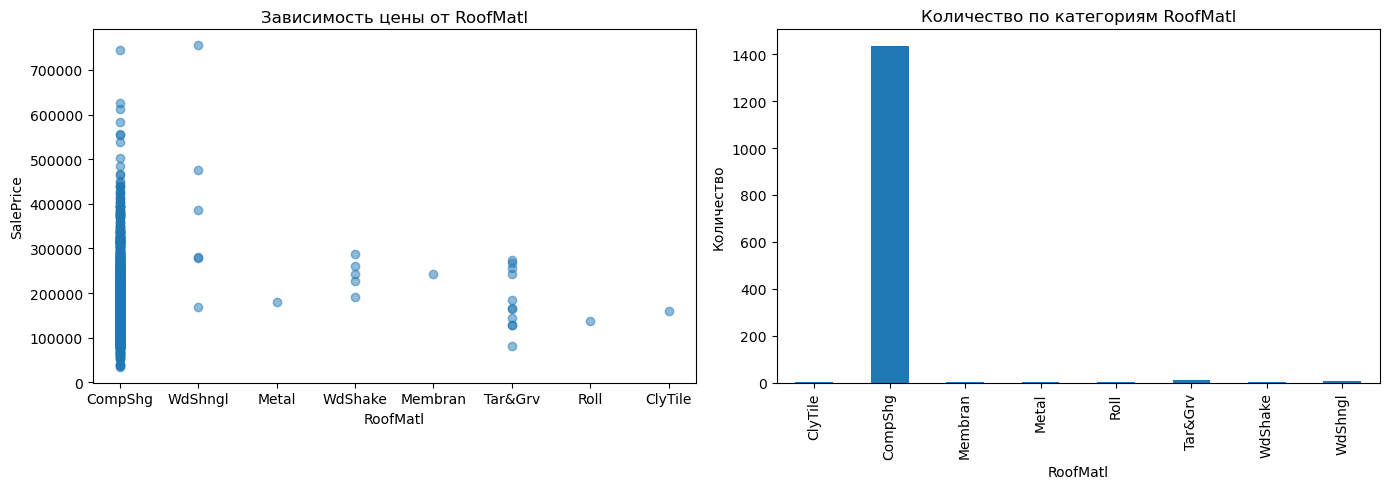

In [34]:
graph_show_to_price("RoofMatl", bins=-1)

In [35]:
quantitative = [f for f in df.columns if df.dtypes[f] != 'object']
quantitative.remove('SalePrice')
quantitative.remove('Id')
qualitative = [f for f in df.columns if df.dtypes[f] == 'object']

C:\Users\Faceless\AppData\Local\Temp\ipykernel_23224\3299039672.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(y, kde=False, fit=st.johnsonsu)
C:\Users\Faceless\AppData\Local\Temp\ipykernel_23224\3299039672.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(y, kde=False, fit=st.norm)
C:\Us

<Axes: title={'center': 'Log Normal'}, xlabel='SalePrice'>

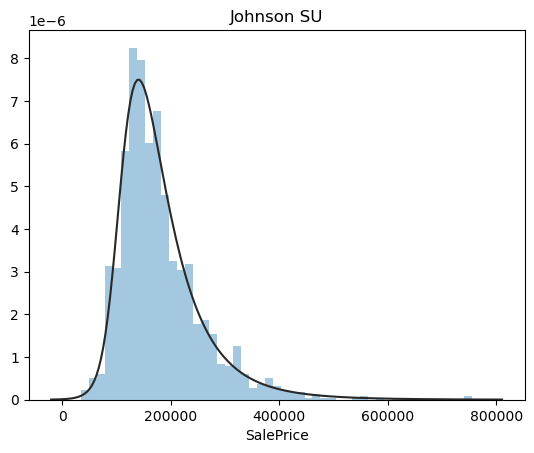

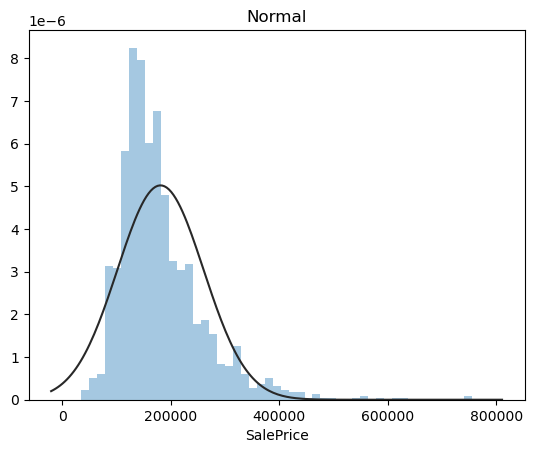

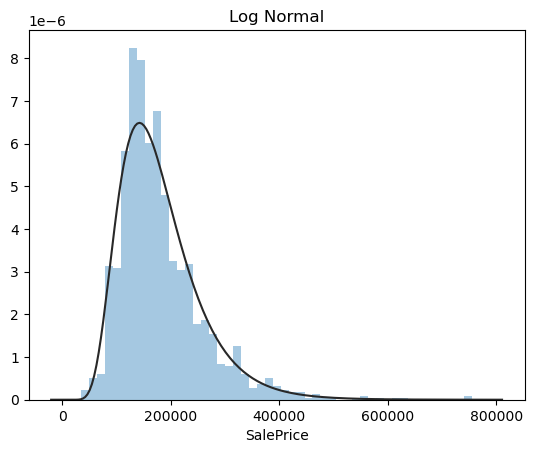

In [36]:
import scipy.stats as st
import seaborn as sns
y = df['SalePrice']
plt.figure(1); plt.title('Johnson SU')
sns.distplot(y, kde=False, fit=st.johnsonsu)
plt.figure(2); plt.title('Normal')
sns.distplot(y, kde=False, fit=st.norm)
plt.figure(3); plt.title('Log Normal')
sns.distplot(y, kde=False, fit=st.lognorm)

C:\Users\Faceless\AppData\Local\Temp\ipykernel_23224\4242138302.py:10: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  pval = stats.f_oneway(*samples)[1]


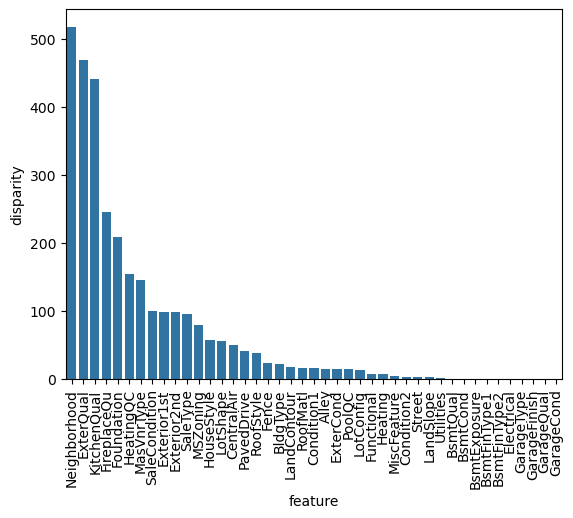

In [37]:
def anova(frame):
    anv = pd.DataFrame()
    anv['feature'] = qualitative
    pvals = []
    for c in qualitative:
        samples = []
        for cls in frame[c].unique():
            s = frame[frame[c] == cls]['SalePrice'].values
            samples.append(s)
        pval = stats.f_oneway(*samples)[1]
        pvals.append(pval)
    anv['pval'] = pvals
    return anv.sort_values('pval')

a = anova(df)
a['disparity'] = np.log(1./a['pval'].values)
sns.barplot(data=a, x='feature', y='disparity')
x=plt.xticks(rotation=90)

NameError: name 'qual_encoded' is not defined

In [40]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Id,1460.0,730.500000,421.610009,1.0,365.75,730.5,1095.25,1460.0
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1460.0,70.199658,22.431902,21.0,60.00,70.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0


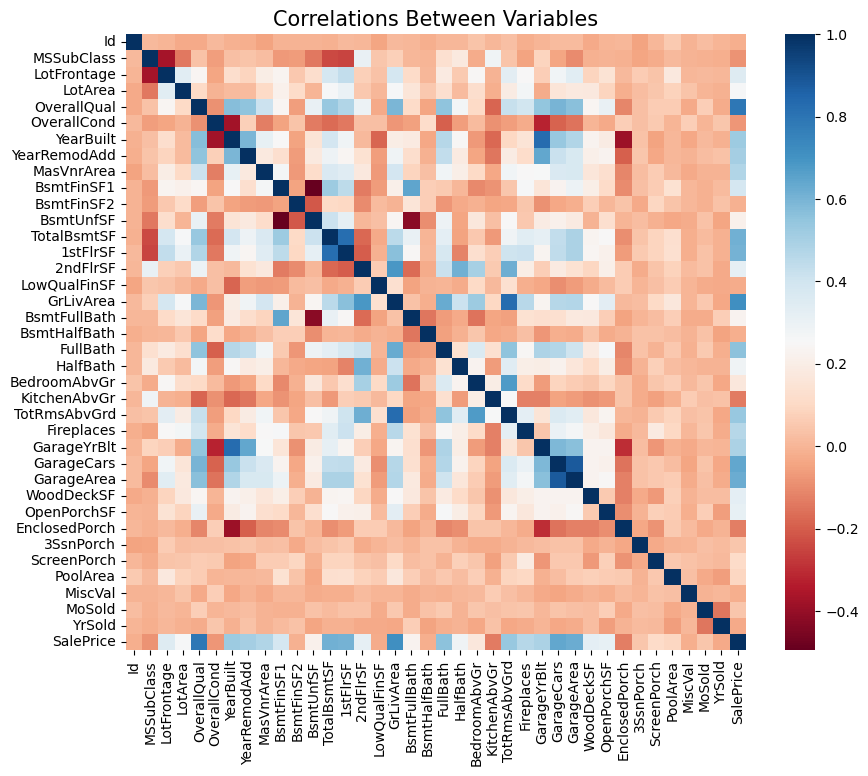

In [42]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), cmap="RdBu")
plt.title("Correlations Between Variables", size=15)
plt.show()

In [44]:
important_num_cols = list(df.corr(numeric_only=True)["SalePrice"][(df.corr(numeric_only=True)["SalePrice"]>0.50) | (df.corr(numeric_only=True)["SalePrice"]<-0.50)].index)
cat_cols = ["MSZoning", "Utilities","BldgType","Heating","KitchenQual","SaleCondition","LandSlope"]
important_cols = important_num_cols + cat_cols

df = df[important_cols]

In [46]:
important_cols

['OverallQual',
 'YearBuilt',
 'YearRemodAdd',
 'TotalBsmtSF',
 '1stFlrSF',
 'GrLivArea',
 'FullBath',
 'TotRmsAbvGrd',
 'GarageCars',
 'GarageArea',
 'SalePrice',
 'MSZoning',
 'Utilities',
 'BldgType',
 'Heating',
 'KitchenQual',
 'SaleCondition',
 'LandSlope']

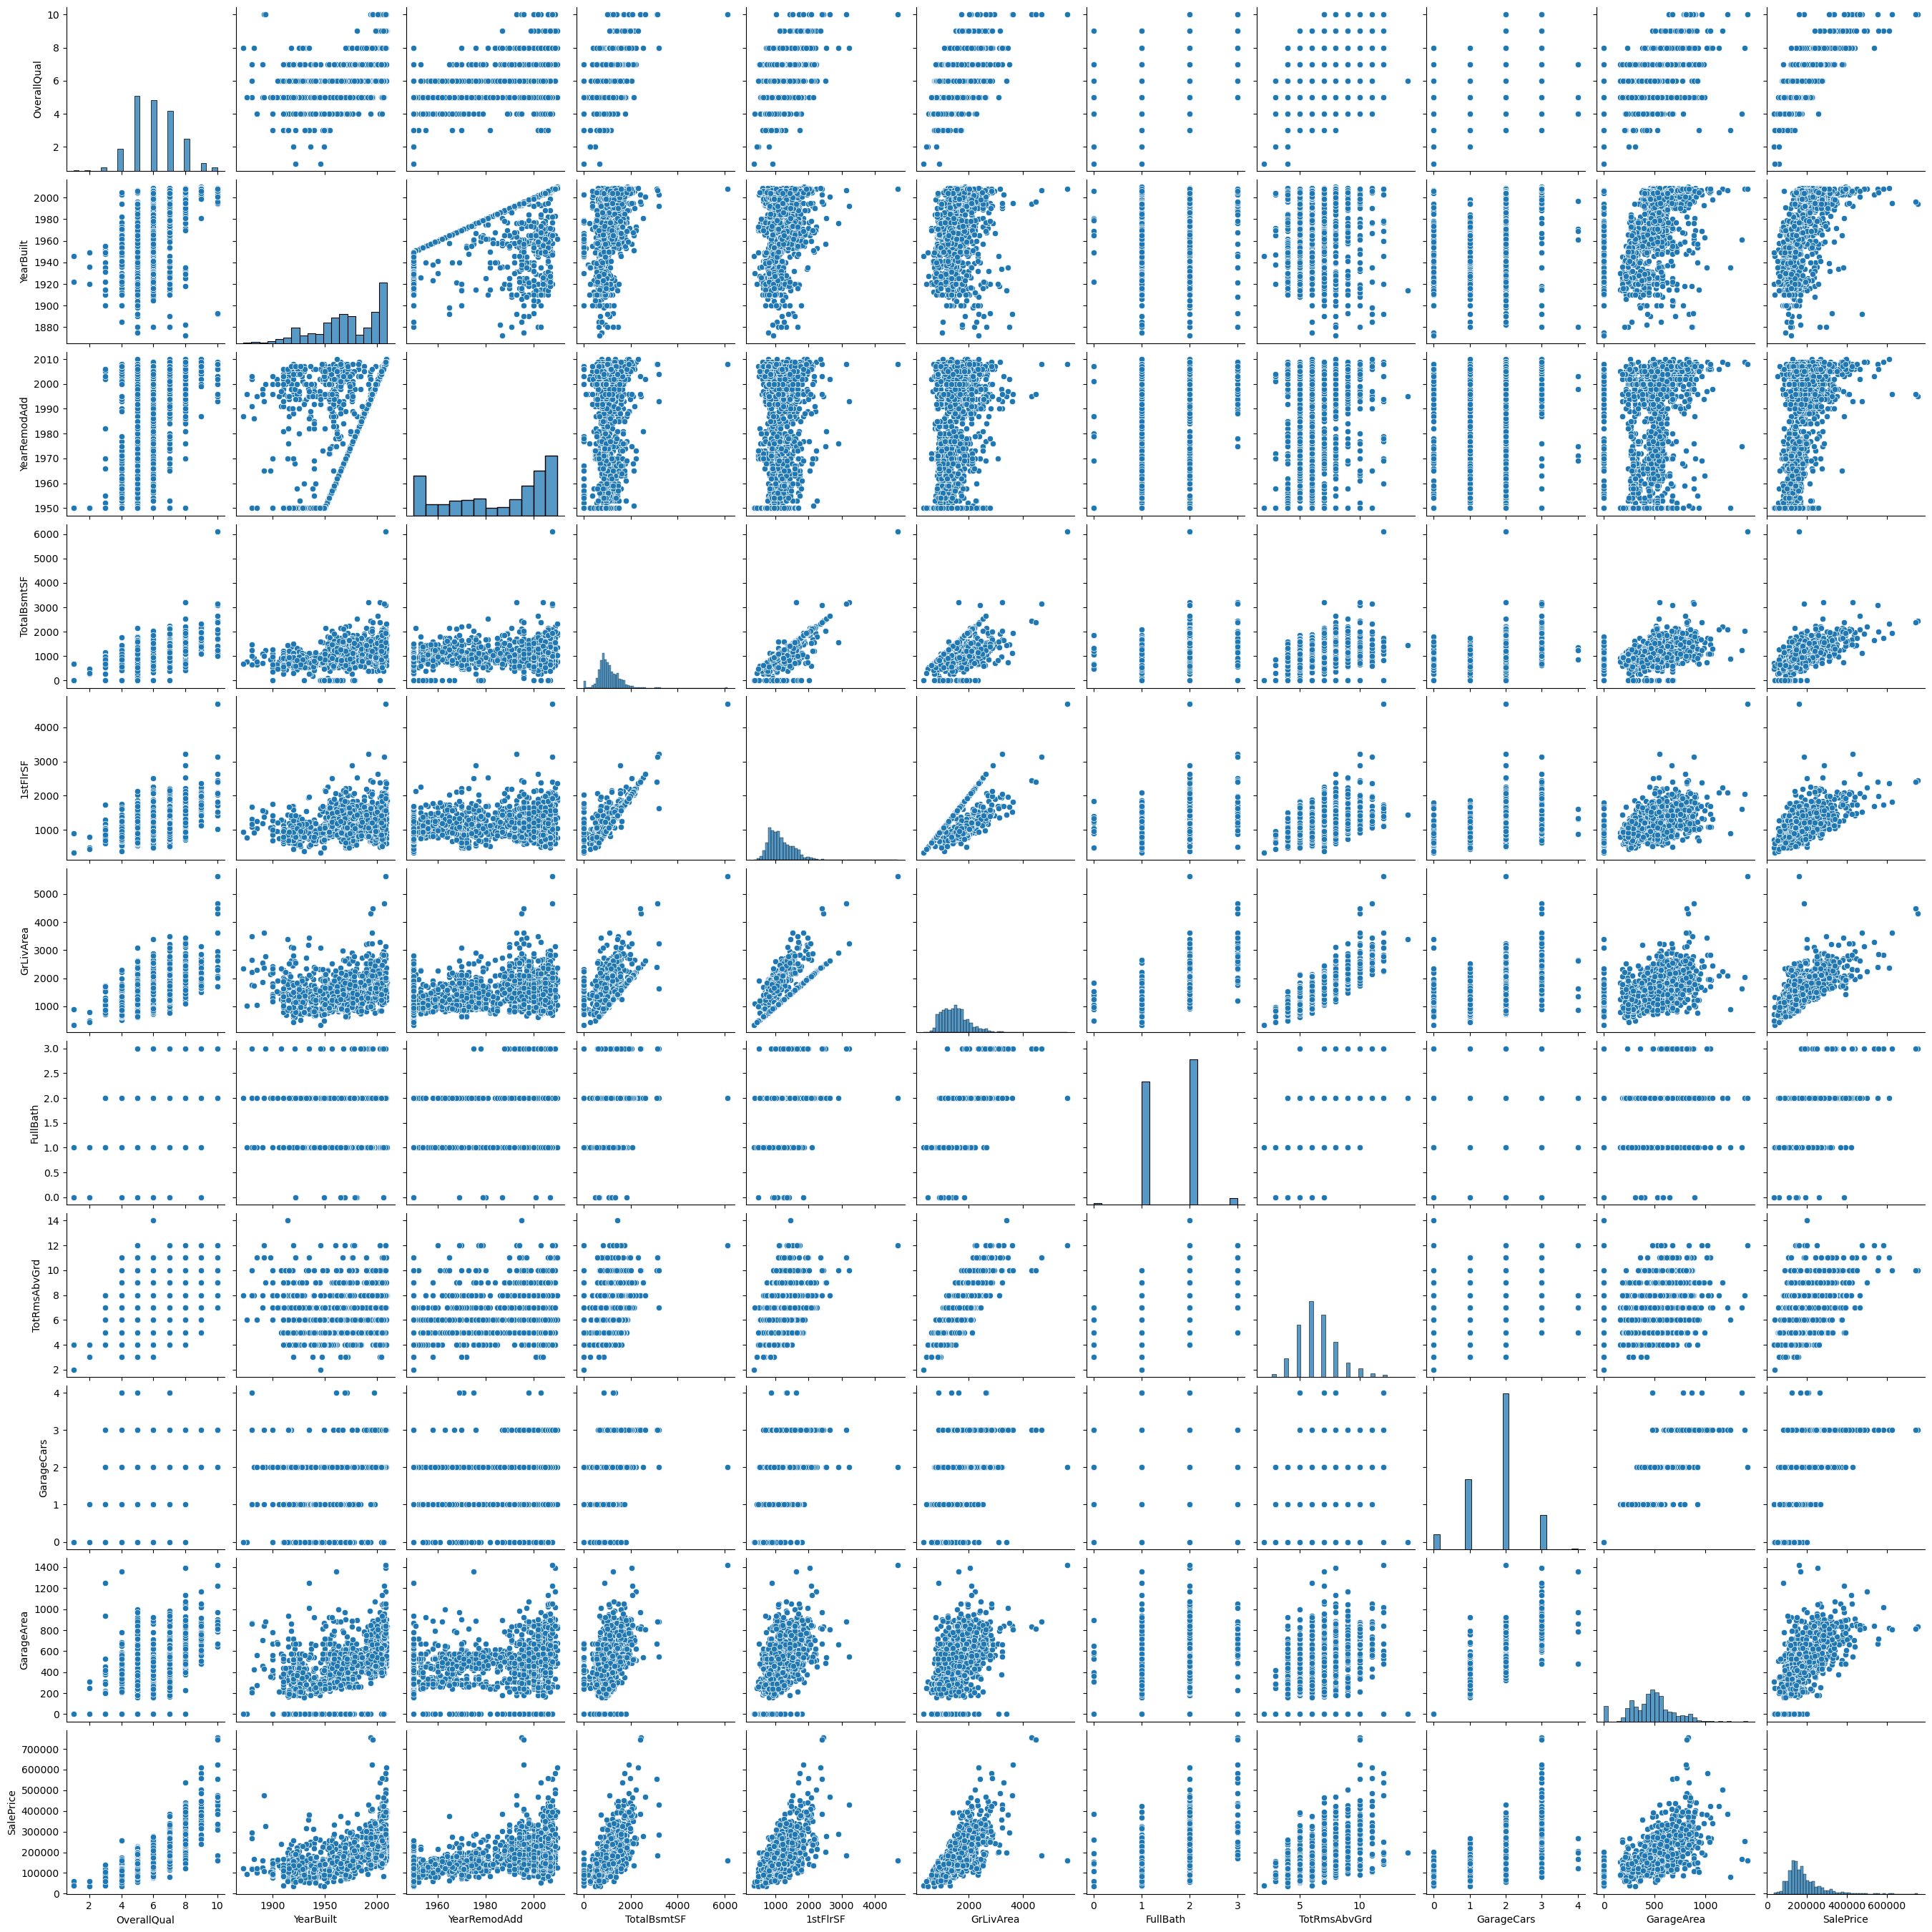

In [47]:
sns.pairplot(df[important_num_cols])